# Evaluate IC50 for statin analogues

In [1]:
import tensorflow as tf
import numpy as np
import pandas as pd
import deepchem as dc
import time
import transformers
import random
import mordred
from rdkit import Chem
import matplotlib.pyplot as plt
from rdkit.Chem import AllChem, Draw
from sklearn.model_selection import train_test_split
from deepchem.feat.smiles_tokenizer import SmilesTokenizer
from rdkit import DataStructs
from rdkit.Chem.Fingerprints import FingerprintMols

from rdkit.Chem import RDConfig
import sys, os
sys.path.append(os.path.join(RDConfig.RDContribDir,'SA_Score'))
import sascorer


Instructions for updating:
experimental_relax_shapes is deprecated, use reduce_retracing instead


Skipped loading modules with pytorch-geometric dependency, missing a dependency. No module named 'torch_geometric'
Skipped loading modules with pytorch-geometric dependency, missing a dependency. cannot import name 'DMPNN' from 'deepchem.models.torch_models' (C:\ProgramData\Anaconda3\envs\rdkitenv\lib\site-packages\deepchem\models\torch_models\__init__.py)
Skipped loading some Jax models, missing a dependency. No module named 'jax'


In [ ]:
#!pip install deepchem

## Setup for Statin MLP
- Load a pre-trained MLP that predicts Statin IC50
- Set-up the featurizer needed for the Statin MLP

In [3]:
#featurizer=dc.feat.RDKitDescriptors()
#featname="RDKitDescriptors"
featurizer=dc.feat.MordredDescriptors()
featname="MordredDescriptors"

mlp_df = pd.read_csv("905-unique-statins.csv")
mlp_x = [""]*len(mlp_df)
i=0
for name in mlp_df["Ligand SMILES"]:
    mlp_x[i]=name.replace("[Na+].","").replace(".[Na+]","")
    i += 1
mlp_x = list(mlp_x)

mlp_mols = [Chem.MolFromSmiles(smile) for smile in mlp_x]
mlp_f = featurizer.featurize(mlp_mols)

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scalername = "StandardScaler"
scaler.fit(mlp_f)
mlp_scaled = scaler.transform(mlp_f)

from sklearn.decomposition import PCA
pca = PCA(n_components=75)
pca.fit(mlp_scaled)

Statin_MLP = tf.keras.models.load_model("11May_MorPCA75_2B_FT_4x400AdamRelu_150epcs")
Statin_MLP.compile()
Statin_MLP.summary()

print("MLP model loaded and PCA prepared")

C:\ProgramData\Anaconda3\envs\rdkitenv\lib\site-packages\numpy\core\fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)





Model: "model_14"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_16 (InputLayer)       [(None, 75)]              0         
                                                                 
 normalization_15 (Normaliz  (None, 75)                151       
 ation)                                                          
                                                                 
 skip_dense_block_25 (SkipD  (None, 400)               511600    
 enseBlock)                                                      
                                                                 
 skip_dense_block_26 (SkipD  (None, 800)               641600    
 enseBlock)                                                      
                                                                 
 dense_119 (Dense)           (None, 1)                 801       
                                                       

In [4]:
known_df = pd.read_csv("known_statins.csv")
#================================================================
#use this code to test chembl list
#known_df = pd.read_csv("Statin_Chembl_SMILES.csv")
#=================================================================
known_smiles = [""]*len(known_df["SMILES"])
for i,name in enumerate(known_df["SMILES"]):
    known_smiles[i]=name.replace("[Na+].","").replace(".[Na+]","").replace(".[Ca+2]","")
knowns = known_smiles

mol_pred_batch = []
for smile in knowns:
    mol = Chem.MolFromSmiles(smile)
    mol_pred_batch.append(mol)
    
featurized_pred_batch = featurizer.featurize(mol_pred_batch)
scaled_pred_batch = scaler.transform(featurized_pred_batch)
pca_pred_batch = pca.transform(scaled_pred_batch)

predicted_pred_batch = Statin_MLP.predict(pca_pred_batch)

err = []
for name, ic50,exp in zip(known_df["name"],predicted_pred_batch,known_df["exp"]):
  ic50 = np.exp(ic50)
  err.append(abs(ic50-exp))
  print(f"IC50 for {name} is {ic50} and MAE is {abs(ic50-exp)}")
print(f"average error for knows is {sum(err)/len(err)}")

1/1 [==============================] - 0s 469ms/step
IC50 for Cerivastatin is [8.563684] and MAE is [5.0236845]
IC50 for Simvastatin is [7.4389424] and MAE is [4.698942]
IC50 for Atorvastatin is [4.7770524] and MAE is [3.6170526]
IC50 for Rosuvastatin is [3.7036264] and MAE is [3.5436263]
average error for knows is [4.2208266]


In [5]:
def casual_attention_mask(batch_size,n_dest,n_src,dtype):
    i = tf.range(n_dest)[:,None]
    j = tf.range(n_src)
    m = i >= j - n_src + n_dest
    mask = tf.cast(m,dtype)
    mask = tf.reshape(mask,[1,n_dest,n_src])
    mult = tf.concat([tf.expand_dims(batch_size,-1),tf.constant([1,1],dtype=tf.int32)],0)
    return tf.tile(mask,mult)

print("Attention mask built.")

Attention mask built.


In [6]:
class TransformerBlock(tf.keras.layers.Layer):
    def __init__(self,num_heads,key_dim,embed_dim,ff_dim,dropout_rate=0.1):
        super(TransformerBlock,self).__init__()
        self.num_heads = num_heads
        self.key_dim = key_dim
        self.embed_dim = embed_dim
        self.ff_dim = ff_dim
        self.dropout_rate = dropout_rate
        self.attn = tf.keras.layers.MultiHeadAttention(self.num_heads,self.key_dim,
                                                       output_shape=self.embed_dim)
        self.dropout_1 = tf.keras.layers.Dropout(self.dropout_rate)
        self.ln_1 = tf.keras.layers.LayerNormalization(epsilon=0.000001)
        self.ffn_1 = tf.keras.layers.Dense(self.ff_dim,activation="relu")
        self.ffn_2 = tf.keras.layers.Dense(self.embed_dim)
        self.dropout_2 = tf.keras.layers.Dropout(self.dropout_rate)
        self.ln_2 = tf.keras.layers.LayerNormalization(epsilon=0.000001)

    def call(self,inputs):
        input_shape = tf.shape(inputs)
        batch_size2 = input_shape[0]
        seq_len = input_shape[1]
        casual_mask = casual_attention_mask(batch_size2,seq_len,seq_len,tf.bool)
        attention_output, attention_scores = self.attn(inputs,inputs,
                                                       attention_mask=casual_mask,
                                                       return_attention_scores=True)
        attention_output = self.dropout_1(attention_output)
        out1 = self.ln_1(inputs + attention_output)
        ffn_1 = self.ffn_1(out1)
        ffn_2 = self.ffn_2(ffn_1)
        ffn_output = self.dropout_2(ffn_2)
        return (self.ln_2(out1+ffn_output),attention_scores)

    def get_config(self):
        config = super().get_config()
        config.update({"key_dim": self.key_dim, "embed_dim": self.embed_dim,
                      "num_heads": self.num_heads,"ff_dim": self.ff_dim,
                      "dropout_rate": self.dropout_rate})
        return config

print("Transformer Block built.")

Transformer Block built.


In [7]:
class TokenAndPositionEmbedding(tf.keras.layers.Layer):
    def __init__(self,max_len,vocab_size,embed_dim):
        super(TokenAndPositionEmbedding,self).__init__()
        self.max_len = max_len
        self.vocab_size = vocab_size
        self.embed_dim = embed_dim
        self.token_emb = tf.keras.layers.Embedding(input_dim=vocab_size,
                                                    output_dim = embed_dim)
        self.pos_emb = tf.keras.layers.Embedding(input_dim=max_len,output_dim=embed_dim)

    def call(self,x):
        maxlen = tf.shape(x)[-1]
        positions = tf.range(start=0,limit=maxlen,delta=1)
        positions = self.pos_emb(positions)
        x = self.token_emb(x)
        return x + positions

    def get_config(self):
        config = super().get_config()
        config.update({"max_len": self.max_len, "vocab_size": self.vocab_size,
                      "embed_dim": self.embed_dim})
        return config

print("Token and position embedding function built.")

Token and position embedding function built.


## Define helper functions
- This block defines the sequential model and runs the optimization.

- can load previous weights

In [5]:
def strip_smiles(input_string):
    output_string = input_string.replace(" ","").replace("[CLS]","").replace("[SEP]","").replace("[PAD]","")
    output_string = output_string.replace("[Na+].","").replace(".[Na+]","")
    return output_string

def mols_from_smiles(input_smiles_list):
    valid_mols = np.empty([len(input_smiles_list)], dtype="object")
    valid_smiles = [""]*len(input_smiles_list)
    good_count = 0
    for ti, smile in enumerate(input_smiles_list):
       temp_mol = Chem.MolFromSmiles(smile)
       if temp_mol != None:
           valid_mols[good_count] = temp_mol
           valid_smiles[good_count] = smile
           good_count += 1
       else:
           print(f"SMILES {ti} was not valid!")
    print(f"Generated a total of {good_count} mol objects")
    return valid_mols[:good_count], valid_smiles[:good_count]

print("Statin GPT model defined.")

Statin GPT model defined.


Molecules generated by GPT with T = 2.0
Average IC50 for 39 top molecules is: [378.15424]
Average IC50 for 511 molecules is: [inf]


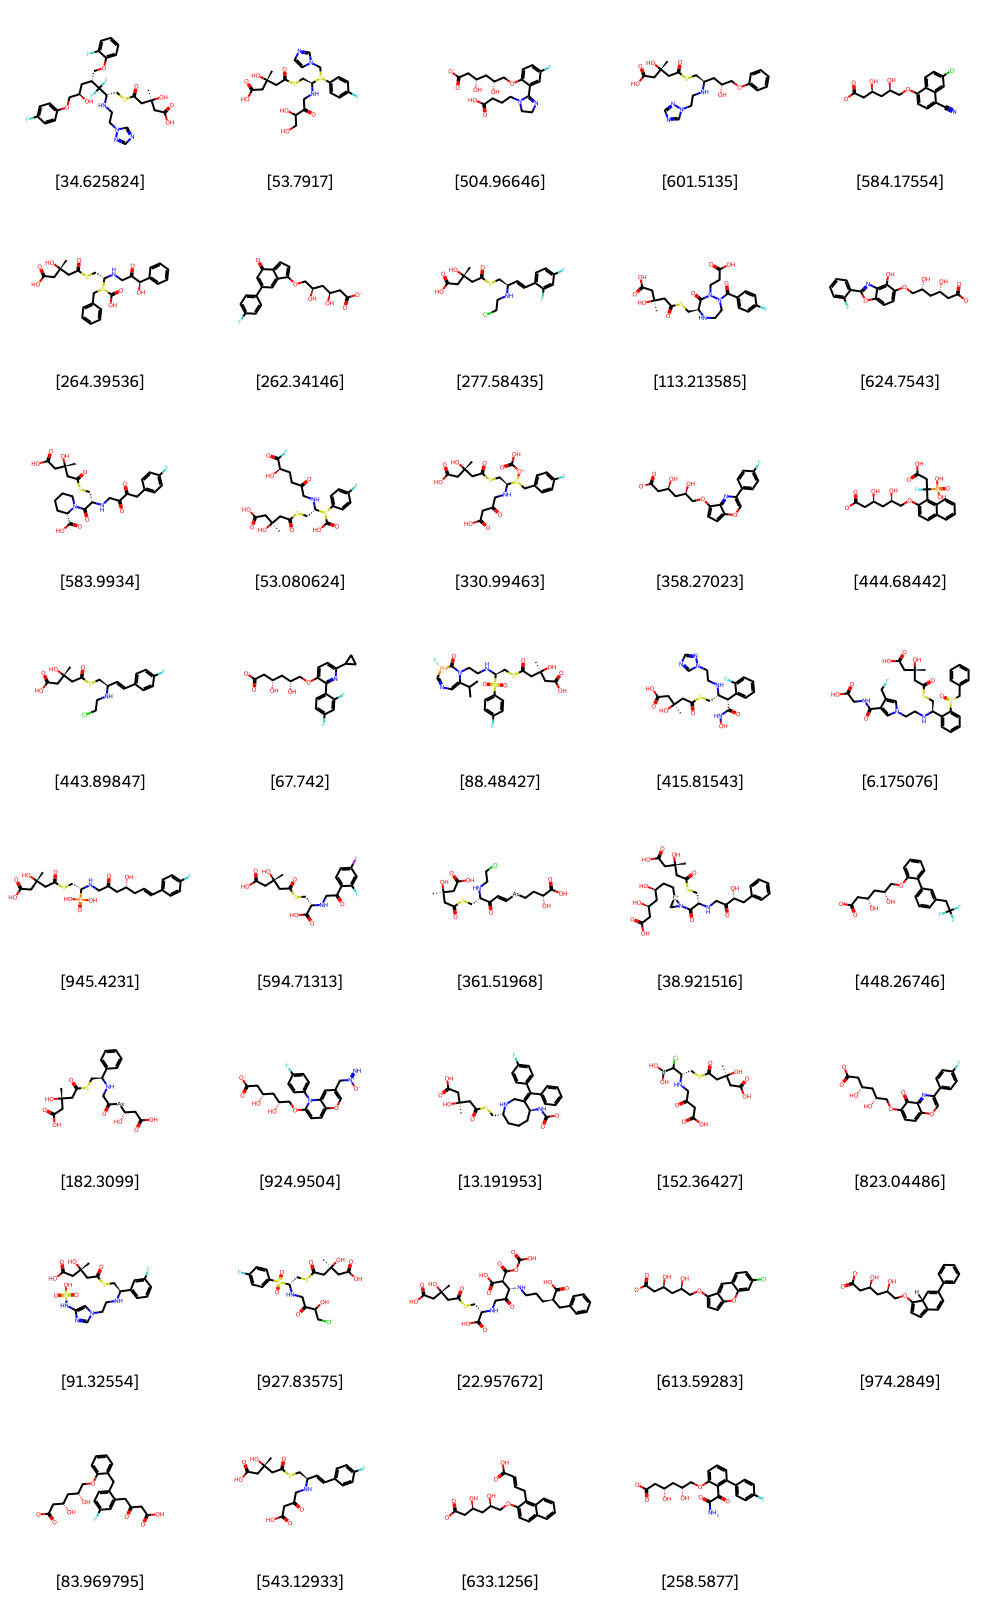

In [36]:
print_legend =[]
print_smiles =[]
print_mols = []

mols_to_plot = list(map(lambda x: Chem.MolFromSmiles(x),res))

count = 0
original_count = 0
average_ic50 = 0.0
average_ic50_total = 0.0
for ic50,good_mol in zip(res2,mols_to_plot):
    average_ic50_total += ic50
    if ic50 < 1000.0:
        average_ic50 += ic50
        print_legend.append(str(ic50))
        print_mols.append(good_mol)
        print_smiles.append(res[original_count])
        count += 1
    original_count += 1

if count == 0:
    leglist = list(map(lambda x: str(x),res2))
    print_mols = mols_to_plot

average_ic50_total = average_ic50_total/original_count
average_ic50 = average_ic50/count
print(f"Molecules generated by GPT with T = {TEMP}")
print(f"Average IC50 for {count} top molecules is: {average_ic50}")
print(f"Average IC50 for {original_count} molecules is: {average_ic50_total}")
    
Draw.MolsToGridImage(mols=print_mols, legends = print_legend, molsPerRow=5,maxMols=50)

In [ ]:
for j in range(count):
    print("Molecule ",j+1)
    wmol = print_mols[j]
    wmol = Chem.AddHs(wmol)
    Chem.AllChem.EmbedMolecule(wmol,
                               useExpTorsionAnglePrefs=True,useBasicKnowledge=True)
    Chem.AllChem.UFFOptimizeMolecule(wmol)
    atoms = wmol.GetAtoms()
    xyz = "\n"
    for i, atom in enumerate(atoms):
        pos = wmol.GetConformer().GetAtomPosition(atom.GetIdx())
        xyz += "{} {} {} {}\n".format(atom.GetSymbol(), pos.x, pos.y, pos.z)
    #xyz += "units angstrom\n"
    print("Structure translated from mol object.")
    #=============================================================================================
    #optionally write the xyz coordinates to a file
    mnst = "generated_molecules/IC50_Temp"+str(TEMP)+"_"+print_legend[j]+".xyz"
    xyzfile = open(mnst,"w")
    xyzfile.write(str(i))
    xyzfile.write(xyz)
    xyzfile.write("\n")
    xyzfile.flush()
    xyzfile.close()
    #=============================================================================================

## Analyze Lists of Molecules

In [37]:
statin_number = 663
read_path = "Gen_results/"
write_path = "Gen_IC50_results/"
read_name = f"statin{statin_number}fullgen15p"
df = pd.read_csv(f"{read_path}{read_name}.csv")
df.head()

,Unnamed: 0,smiles
0,0,O[C@H](C[C@H](O)\C=C\c1c2CCCC(Cc3ccc(cc3)-c3cc...
1,1,N[C@@H](CC(=O)[O-])C[C@H](O)/C=C/c1c2c(nn1-c1c...
2,2,O=C([O-])CC(/C=C/c1c2c(nn1-c1ccc(F)cc1)C(Cc1cc...
3,3,O=C([O-])CC(CCC/C=C/c1c2c(nn1-c1ccc(F)cc1)C(Cc...
4,4,CCC(CCC/C=C/c1c2c(nn1-c1ccc(F)cc1)C(Cc1ccc(-c3...


In [38]:
original_molecules = df["smiles"].to_list()

mol_original_batch,rev_gen_molecules = mols_from_smiles(original_molecules)
featurized_original_batch = featurizer.featurize(mol_original_batch)
scaled_original_batch = scaler.transform(featurized_original_batch)
pca_original_batch = pca.transform(scaled_original_batch)
predicted_original_batch = Statin_MLP.predict(pca_original_batch)
res_original = rev_gen_molecules
res2_original = np.exp(predicted_original_batch)

print_legend =[]
print_mols = []
print_smiles = []

mols_to_plot = list(map(lambda x: Chem.MolFromSmiles(x),res_original))

count = 0
average_ic50 = 0.0
average_ic50_top = 0.0
for ic50,good_mol,smiles in zip(res2_original,mols_to_plot,res_original):
    average_ic50 += ic50
    if ic50 < 1000.0:
        average_ic50_top += ic50
        print_legend.append(str(ic50))
        print_mols.append(good_mol)
        print_smiles.append(smiles)
        count += 1

if count == 0:
    leglist = list(map(lambda x: str(x),res2_original))
    print_mols = mols_to_plot

print("Original set of molecules used as seeds.")
average_ic50 = average_ic50/len(mol_original_batch)
average_ic50_top = average_ic50_top/count

print(f"Average IC50 for {count} top molecules is: {average_ic50_top}")
print(f"Average IC50 for {len(mol_original_batch)} top molecules is: {average_ic50}")

# Calculate simiarity to original molecule ===================================================

all_fp = [AllChem.GetMorganFingerprint(m,2) for m in mols_to_plot]
sim_array = []
for fp in all_fp:
    sim_array.append(DataStructs.TanimotoSimilarity(fp,all_fp[0])) 

# Calculate SAS ===============================================================================

sas_list = []
for mol in mols_to_plot:
    try:
        s = sascorer.calculateScore(mol)
        sas_list.append(s)
    except:
        print("Could not calculate SAS!")
        sas_list.append(-1.0)

# prepare data for CSV ========================================================================

molecules_for_docking = f"{write_path}{read_name}_IC50.csv"
total_ic50_list = list(map(lambda x: str(x[0]),res2_original))
out_dictionary = {"IC50": total_ic50_list, "SMILES": rev_gen_molecules, "SAS": sas_list, "SIMILARITY": sim_array}

out_df = pd.DataFrame.from_dict(out_dictionary)
out_df.to_csv(molecules_for_docking)

print("CSV written.")
    
#Draw.MolsToGridImage(mols=print_mols, legends = print_legend, molsPerRow=5,maxMols=500)

Generated a total of 40 mol objects
2/2 [==============================] - 1s 23ms/step
Original set of molecules used as seeds.
Average IC50 for 35 top molecules is: [245.37299]
Average IC50 for 40 top molecules is: [434.09702]
CSV written.


In [39]:
out_df.head(len(mols_to_plot))

,IC50,SMILES,SAS,SIMILARITY
0,2.9294827,O[C@H](C[C@H](O)\C=C\c1c2CCCC(Cc3ccc(cc3)-c3cc...,3.973030,1.000000
1,593.8041,N[C@@H](CC(=O)[O-])C[C@H](O)/C=C/c1c2c(nn1-c1c...,3.807824,0.694030
2,29.585766,O=C([O-])CC(/C=C/c1c2c(nn1-c1ccc(F)cc1)C(Cc1cc...,3.835870,0.786260
3,93.463356,O=C([O-])CC(CCC/C=C/c1c2c(nn1-c1ccc(F)cc1)C(Cc...,3.924407,0.759398
4,367.91595,CCC(CCC/C=C/c1c2c(nn1-c1ccc(F)cc1)C(Cc1ccc(-c3...,3.798276,0.746269
5,394.37796,C[C@@H](CC(=O)[O-])C[C@H](O)/C=C/c1c2c(nn1-c1c...,3.765002,0.694030
6,162.63298,C[C@@H](CC(=O)[O-])C[C@H](O)/C=C/c1c2c(nn1-c1c...,4.101792,0.531034
7,89.152664,O=C([O-])CC(CO)CCC/C=C/c1c2c(nn1-c1ccc(F)cc1)C...,3.853086,0.759398
8,247.85825,C[C@@H](CC(=O)[O-])C[C@H](O)/C=C/c1c2c(nn1-c1c...,4.131843,0.531034
9,247.85825,C[C@@H](CC(=O)[O-])C[C@H](O)/C=C/c1c2c(nn1-c1c...,4.131843,0.531034


In [ ]:
# analyze statin training set

#pca_original_batch = pca.transform(mlp_scaled)
#predicted_original_batch = Statin_MLP.predict(pca_original_batch)
#==================================================================
#to analyze chembl list below / mlp list above
predicted_original_batch = Statin_MLP.predict(pca_pred_batch)
mlp_x = knowns
#==================================================================
res_original = mlp_x
res2_original = np.exp(predicted_original_batch)

print_legend =[]
print_mols = []
print_smiles = []

mols_to_plot = list(map(lambda x: Chem.MolFromSmiles(x),mlp_x))

count = 0
average_ic50 = 0.0
average_ic50_top = 0.0
for ic50,good_mol,smiles in zip(res2_original,mols_to_plot,mlp_x):
    average_ic50 += ic50
    if ic50 < 1000.0:
        average_ic50_top += ic50
        print_legend.append(str(ic50))
        print_mols.append(good_mol)
        print_smiles.append(smiles)
        count += 1

if count == 0:
    leglist = list(map(lambda x: str(x),res2_original))
    print_mols = mols_to_plot

print("Statin training set.")
average_ic50 = average_ic50/len(mlp_x)
average_ic50_top = average_ic50_top/count

print(f"Average IC50 for {count} top molecules is: {average_ic50_top}")
print(f"Average IC50 for {len(mlp_x)} full set of molecules is: {average_ic50}")

molecules_for_docking = "xfer_Learning_files/Statin_chembl_FULL_Molecules_21May.csv"
total_ic50_list = list(map(lambda x: str(x),res2_original))
out_dictionary = {"IC50": total_ic50_list, "SMILES": mlp_x}

out_df = pd.DataFrame.from_dict(out_dictionary)
out_df.to_csv(molecules_for_docking)

print("CSV written.")
    
Draw.MolsToGridImage(mols=print_mols, legends = print_legend, molsPerRow=5,maxMols=500)

In [ ]:
molecules_for_docking = "xfer_Learning_files/Statin_chembl__FULL_Docking_Molecules_20May.csv"
out_dictionary = {"IC50": print_legend, "SMILES": print_smiles}

out_df = pd.DataFrame.from_dict(out_dictionary)
out_df.to_csv(molecules_for_docking)

print("CSV written.")

In [ ]:
count = 0
average_ic50 = 0.0
for ic50,good_mol in zip(res2_original,mols_to_plot):
    if ic50 < 1e+50:
        average_ic50 += ic50
        count += 1
    else:
        print(f"{ic50} omitted from list")
print(f"Average ic50 for {count} molecules is {average_ic50/count}.")